### Project Title

**Student Placement Prediction and Skill Gap Analysis System**

### Problem Statement

- Educational institutions and students often find it difficult to identify the factors that influence placement outcomes and employability. Students may have strong academic performance but lack the technical or soft skills required by recruiters. This makes it challenging to assess placement readiness and take corrective actions in time.

### Objectives
- Analyze factors affecting student placements.
- Predict placement status (Placed / Not Placed).
- Estimate placement probability for each student.
- Identify skills that negatively impact placement chances.
- Recommend areas for improvement, certifications, and skill development.
- Build an interactive web application using Streamlit for real-time predictions.

### Expected Outcome

**The system will:**

- Predict a student's placement chances.
- Highlight weak areas such as coding, communication, aptitude, or lack of internships.
- Provide actionable recommendations to improve employability.
- Help students prepare more effectively for campus recruitment.

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
# loading data from csv file
df=pd.read_csv("Indian_Student_Placement_Dataset_2025.csv")
df

,student_id,gender,age,degree,branch,cgpa,backlogs,internships,certifications,coding_skills,communication_skills,aptitude_score,projects,placed,company_type,package_lpa
0,1,Male,20,BE,Mechanical,8.40,2,2,2,1,3,69,0,0,NaN,0.00
1,2,Female,20,BTech,Electrical,8.60,2,0,5,1,9,81,4,0,NaN,0.00
2,3,Male,22,BCA,Electrical,6.62,3,0,1,1,7,50,1,0,NaN,0.00
3,4,Male,24,BCA,DS,8.01,0,0,4,4,7,47,4,0,NaN,0.00
4,5,Male,24,BCA,Electrical,9.12,2,1,2,4,4,77,4,0,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,11996,Female,20,BCA,CS,7.19,2,0,3,7,7,86,2,1,Startup,9.37
11996,11997,Female,24,BTech,IT,6.09,3,1,5,10,7,52,2,0,NaN,0.00
11997,11998,Male,22,BTech,Mechanical,8.02,0,0,0,8,5,44,0,0,NaN,0.00
11998,11999,Male,20,BE,CS,6.40,0,0,5,9,3,47,3,0,NaN,0.00


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            12000 non-null  int64  
 1   gender                12000 non-null  str    
 2   age                   12000 non-null  int64  
 3   degree                12000 non-null  str    
 4   branch                12000 non-null  str    
 5   cgpa                  12000 non-null  float64
 6   backlogs              12000 non-null  int64  
 7   internships           12000 non-null  int64  
 8   certifications        12000 non-null  int64  
 9   coding_skills         12000 non-null  int64  
 10  communication_skills  12000 non-null  int64  
 11  aptitude_score        12000 non-null  int64  
 12  projects              12000 non-null  int64  
 13  placed                12000 non-null  int64  
 14  company_type          3652 non-null   str    
 15  package_lpa           12000 no

In [8]:

df.columns

Index(['student_id', 'gender', 'age', 'degree', 'branch', 'cgpa', 'backlogs',
       'internships', 'certifications', 'coding_skills',
       'communication_skills', 'aptitude_score', 'projects', 'placed',
       'company_type', 'package_lpa'],
      dtype='str')

In [9]:
df.shape

(12000, 16)

In [11]:
df.describe()

,student_id,age,cgpa,backlogs,internships,certifications,coding_skills,communication_skills,aptitude_score,projects,placed,package_lpa
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,21.988333,7.645308,1.491583,1.501167,2.509000,5.495333,5.500583,69.327833,2.504750,0.304333,2.741692
std,3464.24595,1.422158,1.243433,1.118347,1.123582,1.709092,2.889724,2.888459,17.338207,1.699133,0.460144,4.568126
min,1.00000,20.000000,5.500000,0.000000,0.000000,0.000000,1.000000,1.000000,40.000000,0.000000,0.000000,0.000000
25%,3000.75000,21.000000,6.560000,0.000000,0.000000,1.000000,3.000000,3.000000,54.000000,1.000000,0.000000,0.000000
50%,6000.50000,22.000000,7.645000,1.000000,1.000000,3.000000,5.000000,6.000000,69.000000,3.000000,0.000000,0.000000
75%,9000.25000,23.000000,8.720000,2.000000,3.000000,4.000000,8.000000,8.000000,84.000000,4.000000,1.000000,5.170000
max,12000.00000,24.000000,9.800000,3.000000,3.000000,5.000000,10.000000,10.000000,99.000000,5.000000,1.000000,15.000000


In [13]:
df.drop('company_type', axis=1, inplace=True)

In [14]:
df.isnull().sum()

student_id              0
gender                  0
age                     0
degree                  0
branch                  0
cgpa                    0
backlogs                0
internships             0
certifications          0
coding_skills           0
communication_skills    0
aptitude_score          0
projects                0
placed                  0
package_lpa             0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

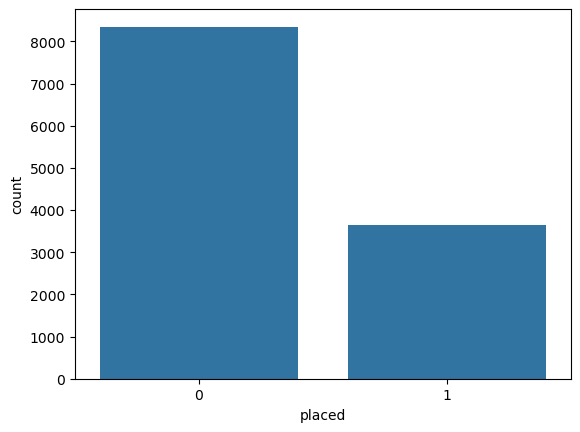

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='placed', data=df)
plt.show()

**Observations from the Placement Distribution Plot**
- Most students are not placed
- The count of students with placed = 0 is much higher than placed = 1.
- This indicates that a larger proportion of students in the dataset were not placed.
  
**Class imbalance exists**
- The dataset is imbalanced because one class (0) has significantly more records than the other class (1).
- Approximately 70% are not placed and 30% are placed.

#### Classification Task
- Problem Type: Binary Classification
- Target Column: placed
  
**Output Classes:**
- 0 → Not Placed
- 1 → Placed

In [25]:
# let us select target variable
y=df["placed"]
# let us select input(X)
# Note: X is same for both regression and classification
#let us verify the shape of the data
X=df.drop(columns=["placed",'student_id',  'package_lpa'])

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            12000 non-null  int64  
 1   gender                12000 non-null  str    
 2   age                   12000 non-null  int64  
 3   degree                12000 non-null  str    
 4   branch                12000 non-null  str    
 5   cgpa                  12000 non-null  float64
 6   backlogs              12000 non-null  int64  
 7   internships           12000 non-null  int64  
 8   certifications        12000 non-null  int64  
 9   coding_skills         12000 non-null  int64  
 10  communication_skills  12000 non-null  int64  
 11  aptitude_score        12000 non-null  int64  
 12  projects              12000 non-null  int64  
 13  placed                12000 non-null  int64  
 14  package_lpa           12000 non-null  float64
dtypes: float64(2), int64(10), str(

In [27]:
# Let us split the data into train data and test data
### let us import train test split from sklarn
from sklearn. model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
### let us verify the shape of the  train and test datasets
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(9600, 12)
(2400, 12)
(9600,)
(2400,)


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

transformer = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), ['gender', 'degree', 'branch']),
        ("num", MinMaxScaler(), ['age', 'cgpa', 'backlogs', 'internships',
                                 'certifications', 'coding_skills',
                                 'communication_skills', 'aptitude_score',
                                 'projects'])
    ]
)

X_train_trans = transformer.fit_transform(X_train)
X_test_trans = transformer.transform(X_test)

In [29]:
y_test.shape

(2400,)

## (a) KNN Classification
### Step:1 Model Training

In [30]:
# let us import knn clasifier
from sklearn.neighbors import KNeighborsClassifier
# Let us define the algorithm parameters
knn_cls = KNeighborsClassifier(n_neighbors=5)
#Let us train the model
knn_cls.fit(X_train_trans,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Step :2 Making Prediction Using Model

In [31]:
# Let us make the prediction using test data
# The predicted out by the model----->y_predicted
# Actual output----->y_test
y_pred=knn_cls.predict(X_test_trans)
print(y_pred.shape)

(2400,)


### Step:3 Validating(testing) the model

In [32]:
# Model Validation
#To validate the model,we need a metric------>accuracy score
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)
print("the accuracy score of the model is:",score)

the accuracy score of the model is: 0.81625


In [33]:
# let us identify classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1685
           1       0.71      0.65      0.68       715

    accuracy                           0.82      2400
   macro avg       0.78      0.77      0.77      2400
weighted avg       0.81      0.82      0.81      2400



### (b) Naive Bayes Model:

In [34]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(X_train_trans,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [35]:
# make predictions with test data
y_pred=nb.predict(X_test_trans)
print(len(y_pred))

2400


In [36]:
# Print Accuracy sore/classification report
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9066666666666666

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train model
dt.fit(X_train_trans, y_train)

# Make predictions
y_pred = dt.predict(X_test_trans)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1685
           1       1.00      1.00      1.00       715

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400


Confusion Matrix:
[[1685    0]
 [   0  715]]


In [38]:
print("Training Accuracy:", dt.score(X_train_trans, y_train))
print("Testing Accuracy:", dt.score(X_test_trans, y_test))

Training Accuracy: 1.0
Testing Accuracy: 1.0


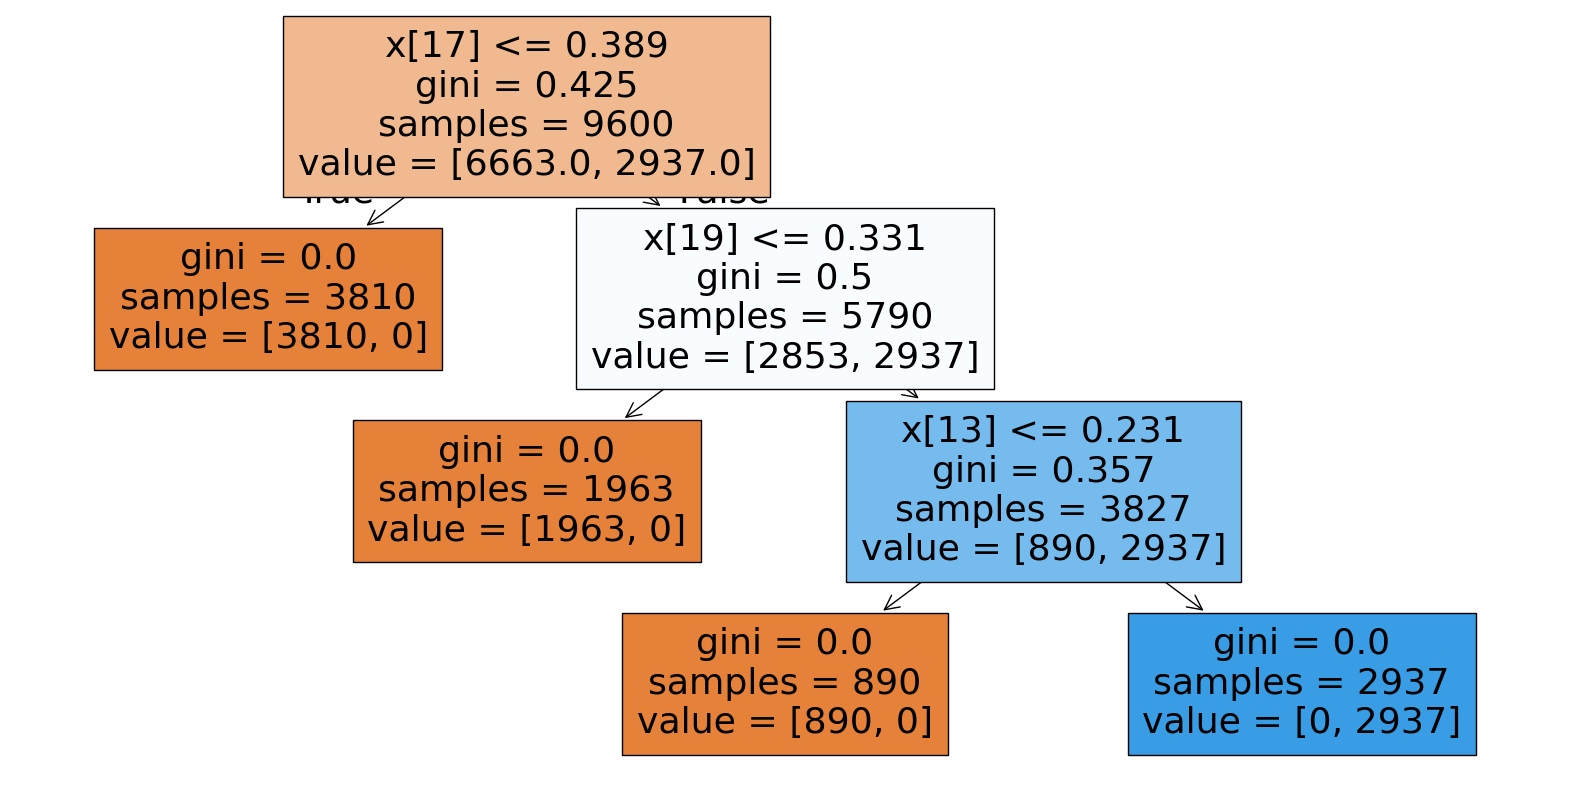

In [39]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt, filled=True)
plt.show()

In [41]:
print(len(X.columns))
print(len(dt.feature_importances_))

12
21


In [43]:
print(X_train_trans.shape)
print(X_test_trans.shape)
print(len(y_train))
print(len(y_test))

(9600, 21)
(2400, 21)
9600
2400


In [44]:
print(len(X.columns))
print(len(dt.feature_importances_))

12
21


In [45]:
feature_names = transformer.get_feature_names_out()

print(len(feature_names))
print(len(dt.feature_importances_))

21
21


In [47]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                      Feature  Importance
19        num__aptitude_score    0.374877
13                  num__cgpa    0.335068
17         num__coding_skills    0.290055
1            cat__gender_Male    0.000000
0          cat__gender_Female    0.000000
4             cat__degree_BSc    0.000000
3              cat__degree_BE    0.000000
2             cat__degree_BCA    0.000000
5           cat__degree_BTech    0.000000
9      cat__branch_Electrical    0.000000
6              cat__branch_AI    0.000000
7              cat__branch_CS    0.000000
8              cat__branch_DS    0.000000
12                   num__age    0.000000
11     cat__branch_Mechanical    0.000000
10             cat__branch_IT    0.000000
14              num__backlogs    0.000000
16        num__certifications    0.000000
15           num__internships    0.000000
18  num__communication_skills    0.000000
20              num__projects    0.000000


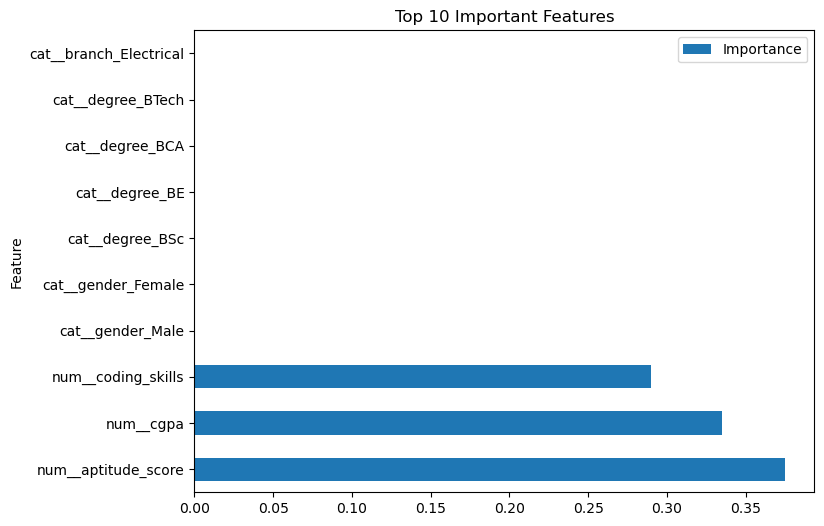

In [48]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,6)
)

plt.title("Top 10 Important Features")
plt.show()

In [49]:
print(type(transformer))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [52]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    "Model": ["KNN", "Naive Bayes", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, knn_cls.predict(X_test_trans)),
        accuracy_score(y_test, nb.predict(X_test_trans)),
        accuracy_score(y_test, dt.predict(X_test_trans))
    ]
})

print(results)

           Model  Accuracy
0            KNN  0.816250
1    Naive Bayes  0.906667
2  Decision Tree  1.000000


In [53]:
print("Training Accuracy:", dt.score(X_train_trans, y_train))
print("Testing Accuracy:", dt.score(X_test_trans, y_test))

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [54]:
import pickle

pickle.dump(nb, open("placement_model.pkl", "wb"))
pickle.dump(transformer, open("transformer.pkl", "wb"))